# Atelier Seaborn — Analyse exploratoire de capteurs IoT

**Contexte :** Une entreprise possède plusieurs bâtiments équipés de capteurs IoT. Chaque capteur collecte régulièrement des informations sur la température, l'humidité, la pression, la consommation énergétique, l'état du capteur, le bâtiment, la date et l'heure de la mesure. Après avoir utilisé NumPy pour manipuler les données numériques, Pandas pour importer, nettoyer et analyser le dataset et Matplotlib pour réaliser des visualisations, l'étape suivante consiste à se servir de Seaborn pour réaliser une analyse exploratoire plus riche des données. 

## Préparation

### 4) Installer et importer seaborn, matplotlib, pandas, numpy

In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid", palette="deep")
%matplotlib inline
# Dossier de sauvegarde des graphiques, créé dès le départ
os.makedirs("../exports", exist_ok=True)

def sauvegarder(nom, formats=("png",)):
    """Sauvegarde le graphique matplotlib/seaborn courant dans exports/, sous chaque format demandé."""
    for fmt in formats:
        plt.savefig(f"../exports/{nom}.{fmt}", dpi=150, bbox_inches="tight")

def sauvegarder_grille(g, nom):
    """Même chose que sauvegarder(), mais pour lmplot()/pairplot() qui renvoient une grille (g), pas une figure plt classique."""
    g.savefig(f"../exports/{nom}.png", dpi=150, bbox_inches="tight")

### 5) Importer `mesures_capteurs.csv` dans le dataframe `df`

In [88]:
df = pd.read_csv("../data/mesures_capteurs.csv")
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


### 6) Vérifier le contenu du dataframe `df`


In [89]:
df.shape


(605, 9)

In [90]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_mesure     605 non-null    str    
 1   date_heure    605 non-null    str    
 2   id_capteur    605 non-null    str    
 3   batiment      605 non-null    str    
 4   temperature   599 non-null    float64
 5   humidite      600 non-null    float64
 6   pression      600 non-null    float64
 7   consommation  600 non-null    float64
 8   etat          601 non-null    str    
dtypes: float64(4), str(5)
memory usage: 42.7 KB


In [91]:
df.describe()

,temperature,humidite,pression,consommation
count,599.000000,600.00000,600.000000,600.000000
mean,24.878314,64.92620,1012.221900,208.675417
std,4.059576,10.76905,10.599042,72.243567
min,-18.500000,28.52000,850.000000,18.120000
25%,22.570000,58.17250,1006.790000,160.177500
50%,24.860000,65.37500,1012.855000,206.150000
75%,27.275000,71.61500,1017.827500,254.127500
max,58.700000,145.00000,1038.430000,875.000000


In [92]:
df.isnull().sum()

id_mesure       0
date_heure      0
id_capteur      0
batiment        0
temperature     6
humidite        5
pression        5
consommation    5
etat            4
dtype: int64

---
## Partie 1 – Distribution d'une variable avec `histplot()`

### 1) Afficher la distribution des temperatures

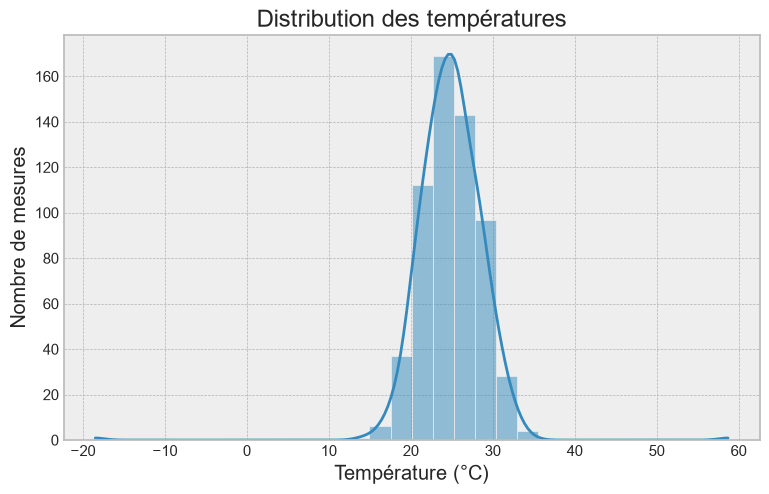

In [128]:
sns.set_theme(style="darkgrid", palette="pastel")
plt.style.use("bmh")
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="temperature", bins=30, kde=True)
plt.title("Distribution des températures")
plt.xlabel("Température (°C)")
plt.ylabel("Nombre de mesures")
sauvegarder("temperature", formats=("png", "pdf"))

plt.show()

### 2) Autour de quelle valeur les températures sont concentrées ?

D’après l’histogramme, les températures sont principalement concentrées autour de 25 °C. La majorité des mesures se trouve dans une zone assez proche de cette valeur.

### 3) La distribution semble-t-elle symétrique ?

Oui, la distribution est globalement assez symétrique autour de sa valeur centrale. Elle présente une forme proche d’une courbe en cloche, avec une forte concentration des températures au centre et moins de mesures lorsqu’on s’éloigne de cette zone.

### 4) Existe-t-il des valeurs extrêmes ?

Oui. On remarque quelques valeurs très éloignées de la majorité des observations, notamment aux deux extrémités de l’histogramme. Elles sont très peu nombreuses et peuvent correspondre à des valeurs anormales ou à des erreurs de mesure.

### 5) Modifier le nombre de classes (bins)

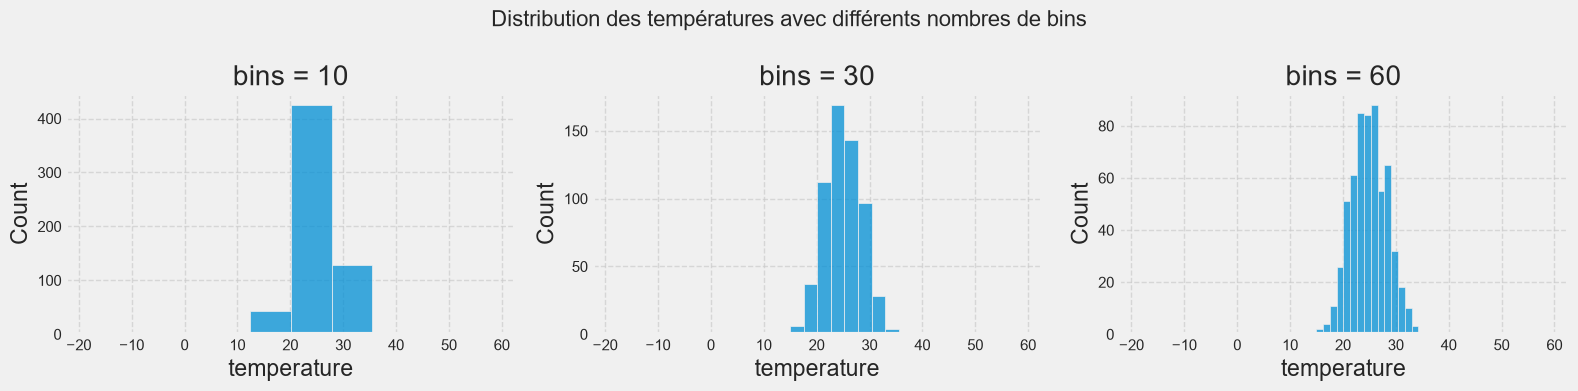

In [127]:
sns.set_theme(style="darkgrid", palette="bright")
plt.style.use("fivethirtyeight")
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(data=df, x="temperature", bins=10, ax=axes[0])
axes[0].set_title("bins = 10")

sns.histplot(data=df, x="temperature", bins=30, ax=axes[1])
axes[1].set_title("bins = 30")

sns.histplot(data=df, x="temperature", bins=60, ax=axes[2])
axes[2].set_title("bins = 60")

plt.suptitle("Distribution des températures avec différents nombres de bins", fontsize=16)
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
sauvegarder("histplot_temperature_bins_comparaison", formats=("png", "pdf"))
plt.show()

### 6) Afficher la distribution des températures par bâtiment 

**Observation :** avec peu de classes (`bins=10`), on voit la tendance générale mais on perd du détail. Avec beaucoup de classes (`bins=60`), on voit mieux les valeurs extrêmes isolées, mais le graphique devient plus "bruité". `bins=30` est un bon compromis ici.

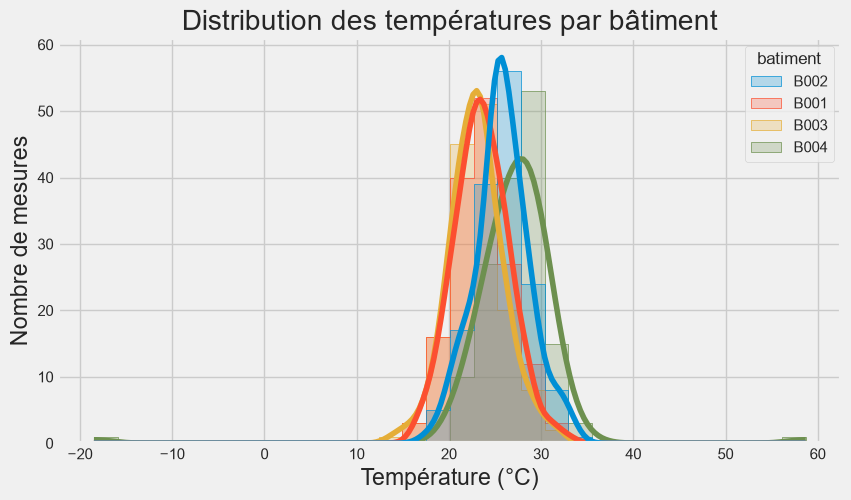

In [95]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x="temperature", hue="batiment", bins=30, kde=True, element="step")
plt.title("Distribution des températures par bâtiment")
plt.xlabel("Température (°C)")
plt.ylabel("Nombre de mesures")
sauvegarder("histplot_temperature_par_batiment", formats=("png", "pdf"))
plt.show()

---
## Partie 2 – Distribution d'une variable avec `kdeplot()`

### 1) Afficher la distribution des températures

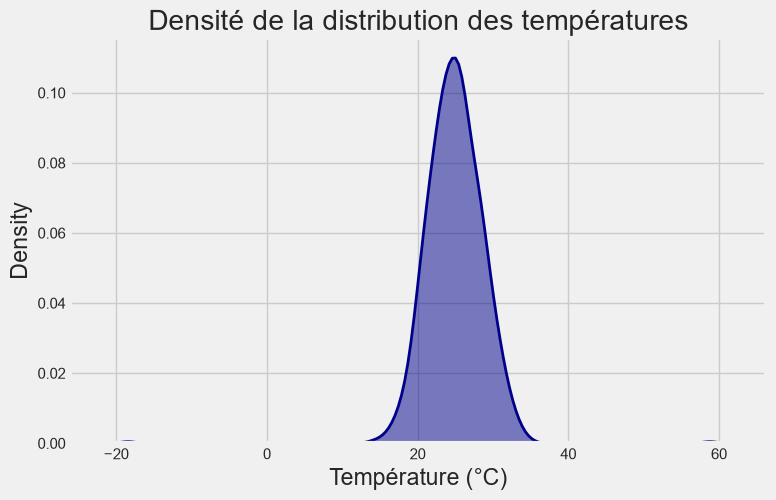

In [126]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x="temperature", fill=True,color="darkblue", alpha=0.5, linewidth=2)
plt.title("Densité de la distribution des températures")
plt.xlabel("Température (°C)")
sauvegarder("kdeplot_temperature", formats=("png", "pdf"))
plt.show()

### 2) Afficher la distribution des températures par bâtiment

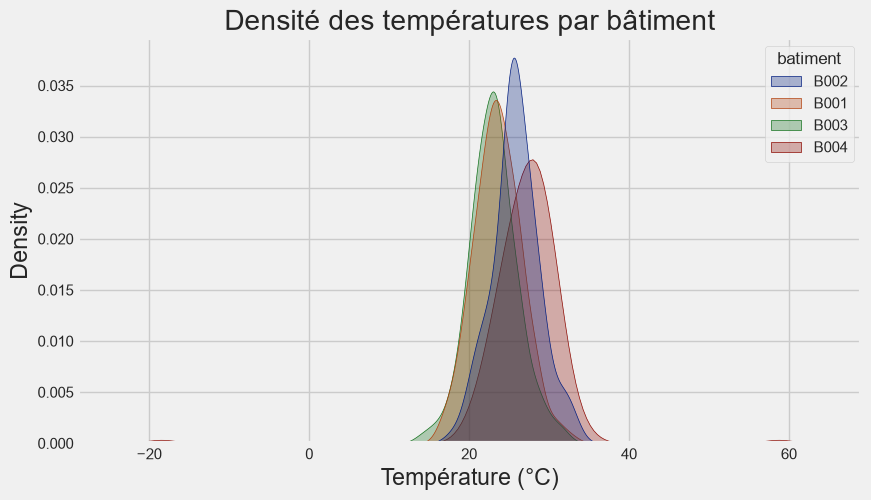

In [124]:
plt.figure(figsize=(9, 5))
sns.kdeplot(data=df, x="temperature", hue="batiment",palette="dark", fill=True, alpha=0.3)
plt.title("Densité des températures par bâtiment")
plt.xlabel("Température (°C)")
sauvegarder("kdeplot_temperature_par_batiment", formats=("png", "pdf"))
plt.show()

---
## Partie 3 – Distribution d'une variable avec `boxplot()`

### 1) Afficher la distribution des températures

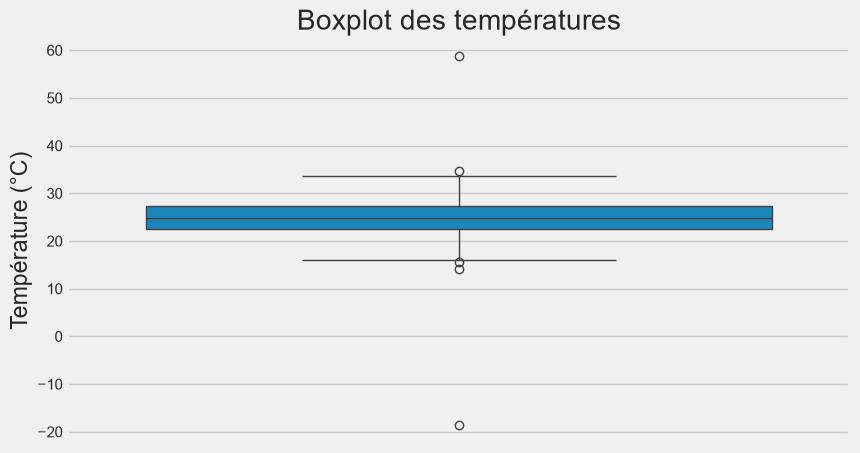

In [123]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, y="temperature")
plt.title("Boxplot des températures")
plt.ylabel("Température (°C)")
sauvegarder("boxplot_temperature", formats=("png", "pdf"))
plt.show()

### 2) Afficher la distribution des températures par bâtiment

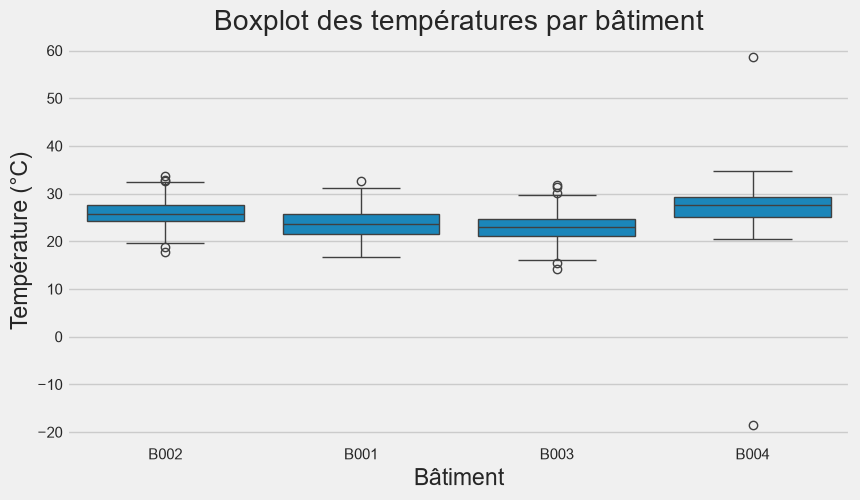

In [122]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="batiment", y="temperature")
plt.title("Boxplot des températures par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Température (°C)")
sauvegarder("boxplot_temperature_par_batiment", formats=("png", "pdf"))

plt.show()

### 3) Pour chaque bâtiment : médiane, dispersion, valeurs extrêmes

In [ ]:
desc_bat = df.groupby("batiment")["temperature"].describe()[["50%", "std", "min", "max"]]
desc_bat.columns = ["mediane", "ecart_type", "min", "max"]
desc_bat

,mediane,ecart_type,min,max
batiment,,,,
B001,23.540,2.961211,16.77,32.72
B002,25.670,2.951828,17.67,33.60
B003,23.045,2.983902,14.11,31.74
B004,27.535,5.367361,-18.50,58.70


**a) Médiane :** lisible directement sur le tableau ci-dessus (colonne `mediane`) ou sur la ligne centrale de chaque boîte du boxplot.

**b) Dispersion :** donnée par la largeur de la boîte (IQR) et confirmée par l'écart-type (`ecart_type`) — plus la boîte est large / l'écart-type est grand, plus les températures de ce bâtiment varient.

**c) Valeurs extrêmes :** ce sont les points isolés affichés en dehors des moustaches du boxplot — visibles pour les bâtiments dont `min` ou `max` s'éloigne beaucoup de la médiane.

### 4) Quels bâtiments ont les valeurs les plus extrêmes ?

In [ ]:
print(f"Minimale la plus basse : {desc_bat['min'].idxmin()} -> {desc_bat['min'].min()}°C")
print(f"Maximale la plus haute : {desc_bat['max'].idxmax()} -> {desc_bat['max'].max()}°C")


Minimale la plus basse : B004 -> -18.5°C
Maximale la plus haute : B004 -> 58.7°C


---
## Partie 4 – Distribution d'une variable avec `violinplot()`

### 1) Afficher la distribution des températures

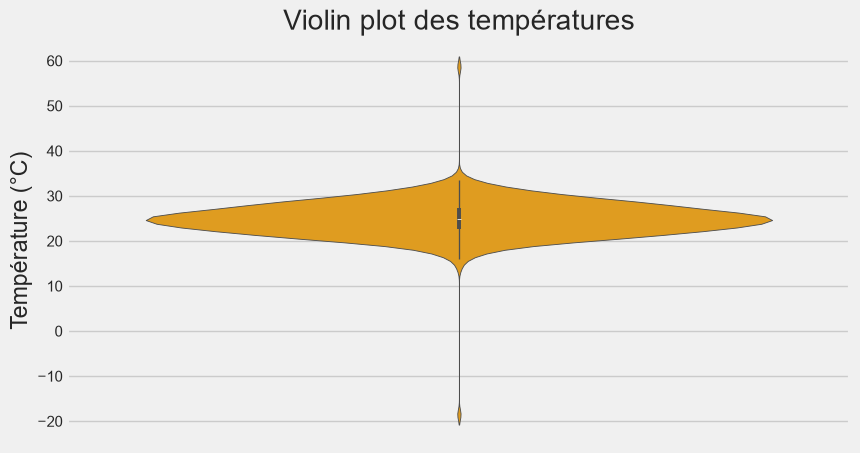

In [121]:
plt.figure(figsize=(9, 5))
sns.violinplot(data=df, y="temperature", color="orange")
plt.title("Violin plot des températures")
plt.ylabel("Température (°C)")
sauvegarder("violinplot_temperature", formats=("png", "pdf"))
plt.show()

### 2) Afficher la distribution des températures par bâtiment

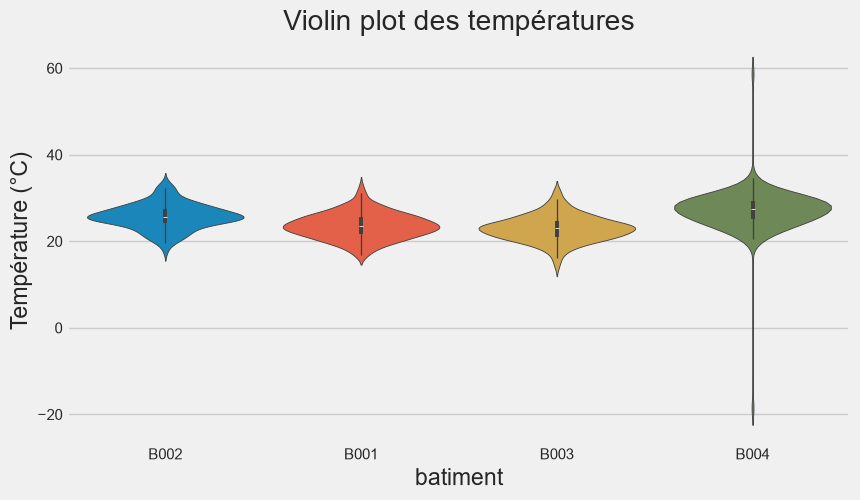

In [120]:
plt.figure(figsize=(9, 5))
sns.violinplot(data=df, x="batiment",y="temperature", hue="batiment")
plt.title("Violin plot des températures")
plt.ylabel("Température (°C)")
sauvegarder("violinplot_temperature_par_batiment", formats=("png", "pdf"))
plt.show()

**3)** Le violin plot montre la forme complète de la distribution des températures, alors que le boxplot ne donne que quelques repères (médiane, quartiles, valeurs extrêmes).

Concrètement, pour chaque bâtiment, le violin plot permet de voir en plus :

- Si les températures se concentrent autour d'une seule valeur habituelle, ou si elles se répartissent en plusieurs zones distinctes (par exemple, un bâtiment chauffé le jour et pas la nuit aurait deux "bosses" de température bien séparées — invisible sur un boxplot, qui ne montrerait qu'une seule boîte)

- Où sont concentrées le plus de mesures à l'intérieur d'une même boîte : le boxplot dit juste "50% des valeurs sont entre Q1 et Q3", mais pas si elles sont plutôt proches de Q1, de Q3, ou bien réparties entre les deux — le violin plot le montre visuellement par sa largeur à chaque hauteur

---
## Partie 5 – Comptage des catégories avec `countplot()`

### 1) Afficher le nombre de mesures par état

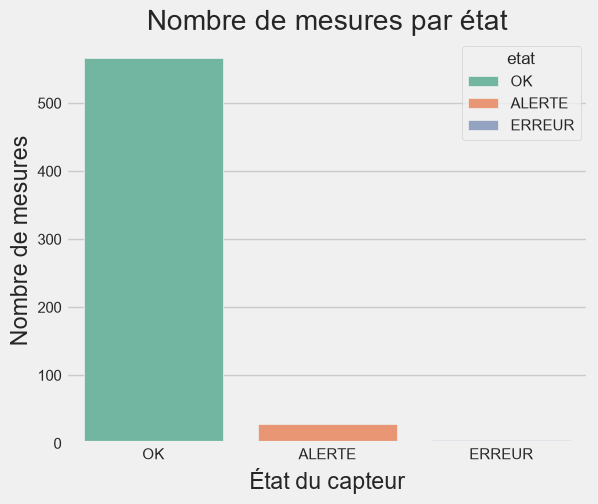

In [119]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="etat", order=df["etat"].value_counts().index,hue="etat", palette="Set2")
plt.title("Nombre de mesures par état")
plt.xlabel("État du capteur")
plt.ylabel("Nombre de mesures")
sauvegarder("countplot_etat", formats=("png", "pdf"))
plt.show()

### 2) Afficher le nombre de mesures par bâtiment

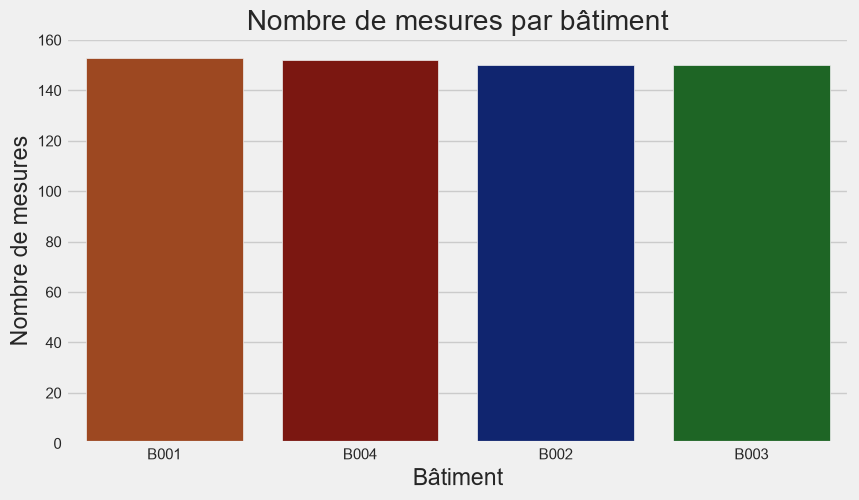

In [118]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x="batiment", order=df["batiment"].value_counts().index,hue="batiment", palette="dark")
plt.title("Nombre de mesures par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Nombre de mesures")
sauvegarder("countplot_batiment", formats=("png", "pdf"))
plt.show()

### 3) États des capteurs par bâtiment

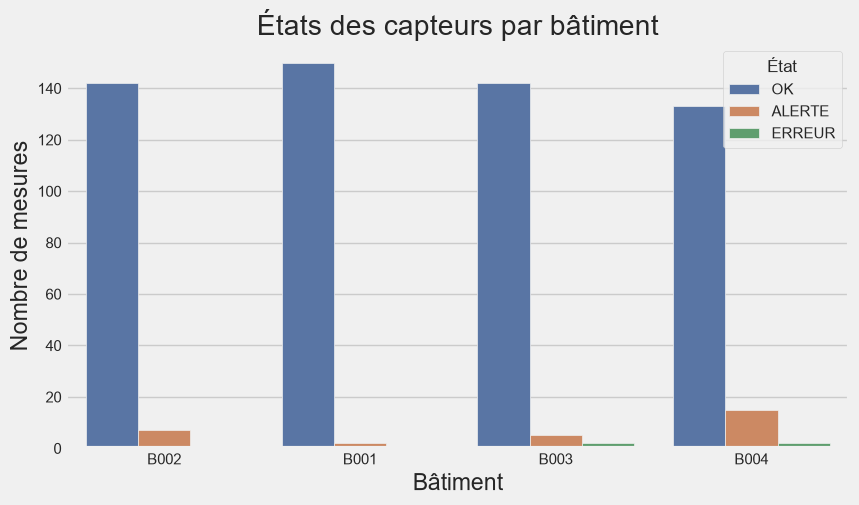

In [117]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x="batiment", hue="etat", palette="deep")
plt.title("États des capteurs par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Nombre de mesures")
plt.legend(title="État")
sauvegarder("countplot_etat_par_batiment", formats=("png", "pdf"))
plt.show()

In [ ]:
tableau_etats = pd.crosstab(df["batiment"], df["etat"])
tableau_etats

etat,ALERTE,ERREUR,OK
batiment,,,
B001,2,1,150
B002,7,0,142
B003,5,2,142
B004,15,2,133


## Partie6: Relation entre deux variables avec scatterplot() 

### 1) Relation entre température et consommation

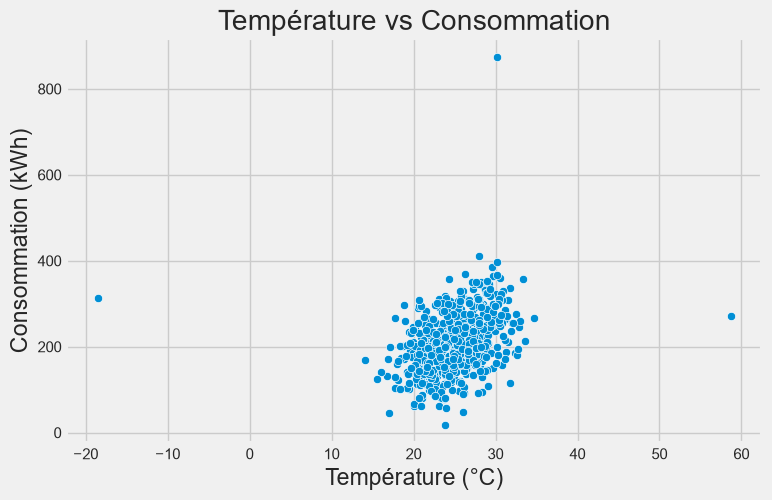

In [116]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="temperature", y="consommation")
plt.title("Température vs Consommation")
plt.xlabel("Température (°C)")
plt.ylabel("Consommation (kWh)")
sauvegarder("scatter_temperature_consommation", formats=("png", "pdf"))
plt.show()

### 2) Relation entre température et consommation par bâtiment

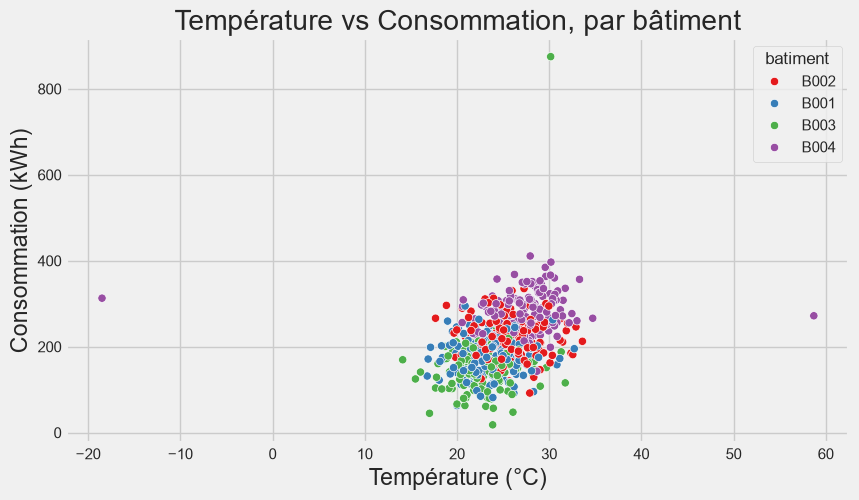

In [115]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x="temperature", y="consommation", hue="batiment", palette="Set1")
plt.title("Température vs Consommation, par bâtiment")
plt.xlabel("Température (°C)")
plt.ylabel("Consommation (kWh)")
sauvegarder("scatter_temperature_consommation_par_batiment", formats=("png", "pdf"))
plt.show()

### 3) Modifier la taille des points

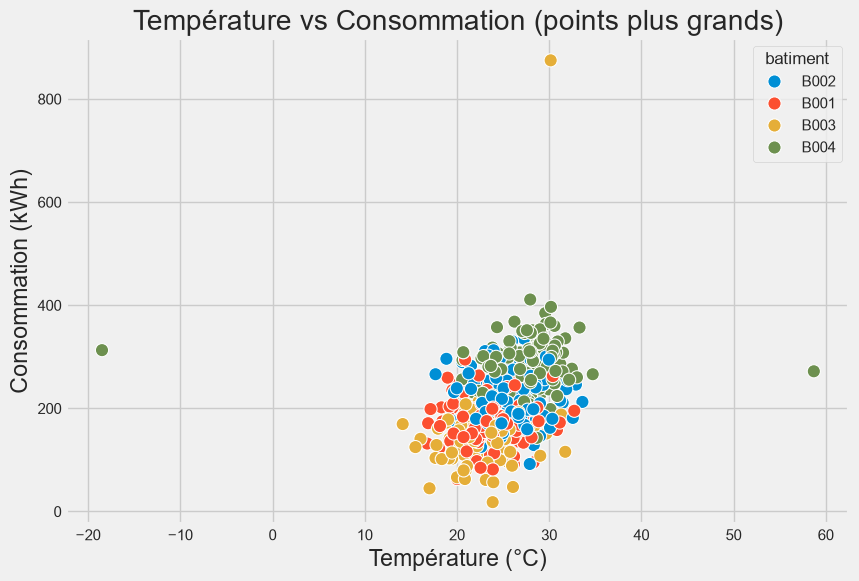

In [114]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="temperature", y="consommation", hue="batiment", s=90)
plt.title("Température vs Consommation (points plus grands)")
plt.xlabel("Température (°C)")
plt.ylabel("Consommation (kWh)")
sauvegarder("scatter_temperature_consommation_taille", formats=("png", "pdf"))
plt.show()

---
## Partie 7 – Régression avec `regplot()`

### Étudier graphiquement une tendance entre température et consommation

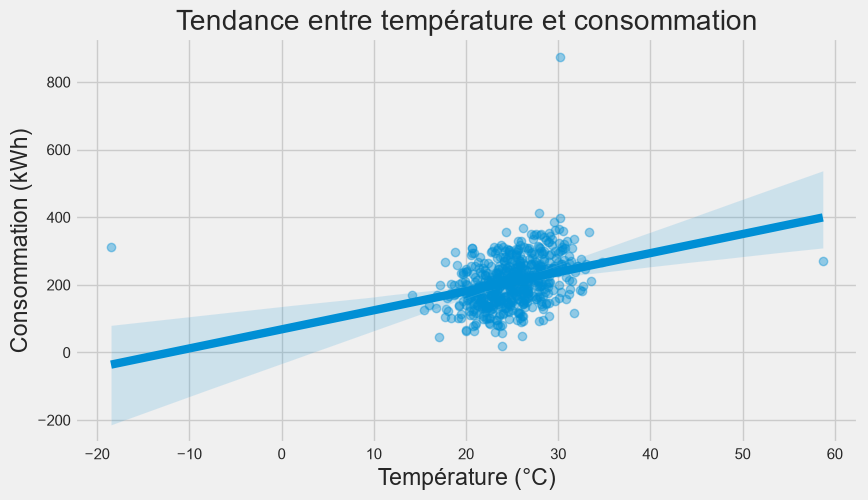

In [113]:
sns.color_palette("dark:#5A9_r", as_cmap=True)
plt.figure(figsize=(9, 5))
sns.regplot(data=df, x="temperature", y="consommation", scatter_kws={"alpha": 0.4})
plt.title("Tendance entre température et consommation")
plt.xlabel("Température (°C)")
plt.ylabel("Consommation (kWh)")
sauvegarder("regplot_temperature_consommation", formats=("png", "pdf"))
plt.show()

---
## Partie 8 – Régression avec `lmplot()`

### Étudier graphiquement une tendance entre température et consommation par bâtiment

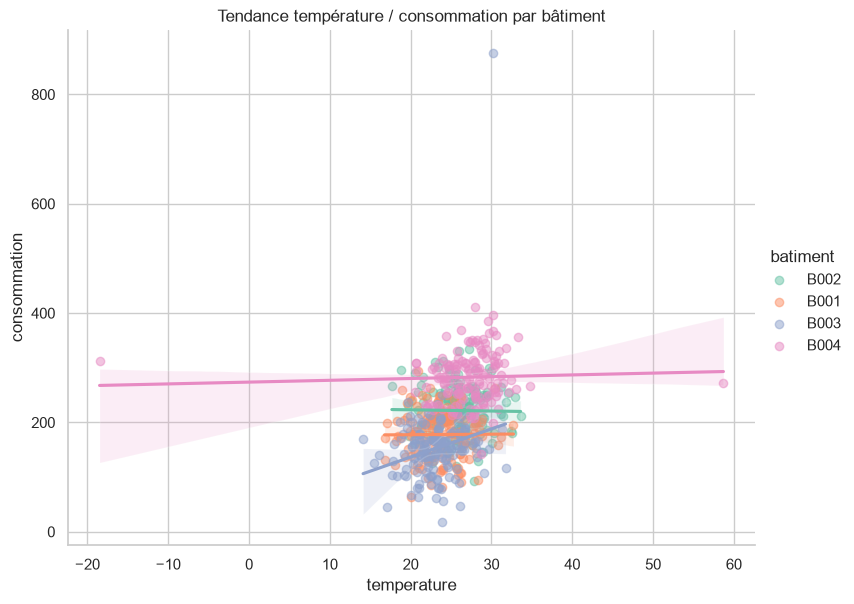

In [ ]:
g=sns.lmplot(data=df, x="temperature", y="consommation", hue="batiment",
           height=6, aspect=1.3, scatter_kws={"alpha": 0.5},palette="Set2")
plt.title("Tendance température / consommation par bâtiment")
sauvegarder_grille(g, "lmplot_temperature_consommation_par_batiment", formats=("png", "pdf"))
plt.show()

---
## Partie 9 – Corrélations

### 1) Calculer les corrélations avec Pandas

In [ ]:
colonnes_num = ["temperature", "humidite", "pression", "consommation"]
correlations = df[colonnes_num].corr()
correlations

,temperature,humidite,pression,consommation
temperature,1.000000,-0.006126,0.061283,0.317048
humidite,-0.006126,1.000000,0.045242,-0.046061
pression,0.061283,0.045242,1.000000,0.056051
consommation,0.317048,-0.046061,0.056051,1.000000


### 2) Afficher la matrice de corrélation obtenue avec Pandas

In [ ]:
print(correlations)

              temperature  humidite  pression  consommation
temperature      1.000000 -0.006126  0.061283      0.317048
humidite        -0.006126  1.000000  0.045242     -0.046061
pression         0.061283  0.045242  1.000000      0.056051
consommation     0.317048 -0.046061  0.056051      1.000000


### 3) Afficher le heatmap de la corrélation

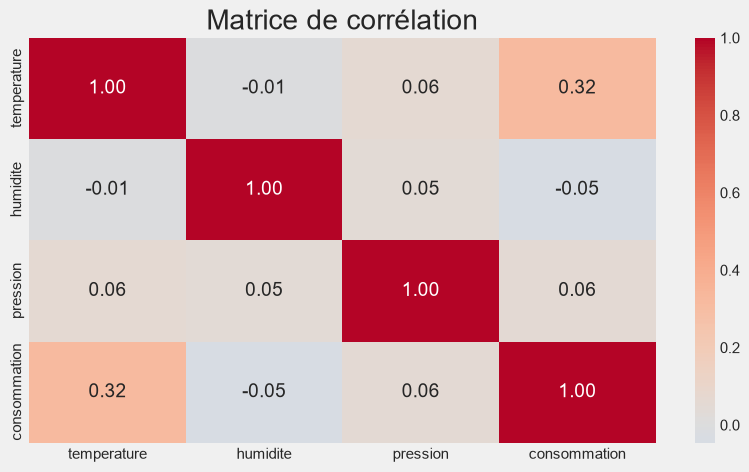

In [97]:
plt.figure(figsize=(9, 5))
sns.heatmap(correlations, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Matrice de corrélation")
sauvegarder("heatmap_correlations" , formats=("png", "pdf"))
plt.show()


## a) Les corrélations positives
Une corrélation positive signifie que lorsque l'une des variables augmente, l'autre a également tendance à augmenter. On les repère par les nuances de couleur orange/rouge (valeurs supérieures à **0**).

* température & consommation : **0.32** (corrélation positive modérée).
* température & pression : **0.06** (corrélation positive très faible).
* pression & consommation : **0.06** (corrélation positive très faible).
* humidité & pression : **0.05** (corrélation positive très faible).

## b) Les corrélations négatives
Une corrélation négative signifie que lorsque l'une des variables augmente, l'autre diminue. On les repère ici par les nuances gris-bleu clair (valeurs inférieures à **0**).

* humidité & consommation : **-0.05** (corrélation négative presque nulle).
* temperature & humidité :  **-0.01** (corrélation négative presque nulle).

## c) Les corrélations proches de zéro
Ces valeurs indiquent une absence totale de relation linéaire entre les deux variables. On retient généralement les valeurs situées entre **-0.1** et **0.1**.

* temperature & humidité **(-0.01)**
* humidité & consommation **(-0.05)**
* humidité & pression **(0.05)**
* température & pression **(0.06)**
* pression & consommation **(0.06)**

## d) Les variables qui semblent fortement liées

* Aucune variable n'est fortement liée.
* Note méthodologique : Les valeurs de **1.00** sur la diagonale (ex: température avec température) représentent la corrélation d'une variable avec elle-même, ce qui est normal et n'apporte pas d'information.
* Le lien le plus **"fort"** (bien qu'il reste modéré) est celui entre la température et la consommation (**0.32**). Cela suggère que la consommation a tendance à grimper lorsque la température augmente .





---
## Partie 10 – Analyse multivariée avec `pairplot()`

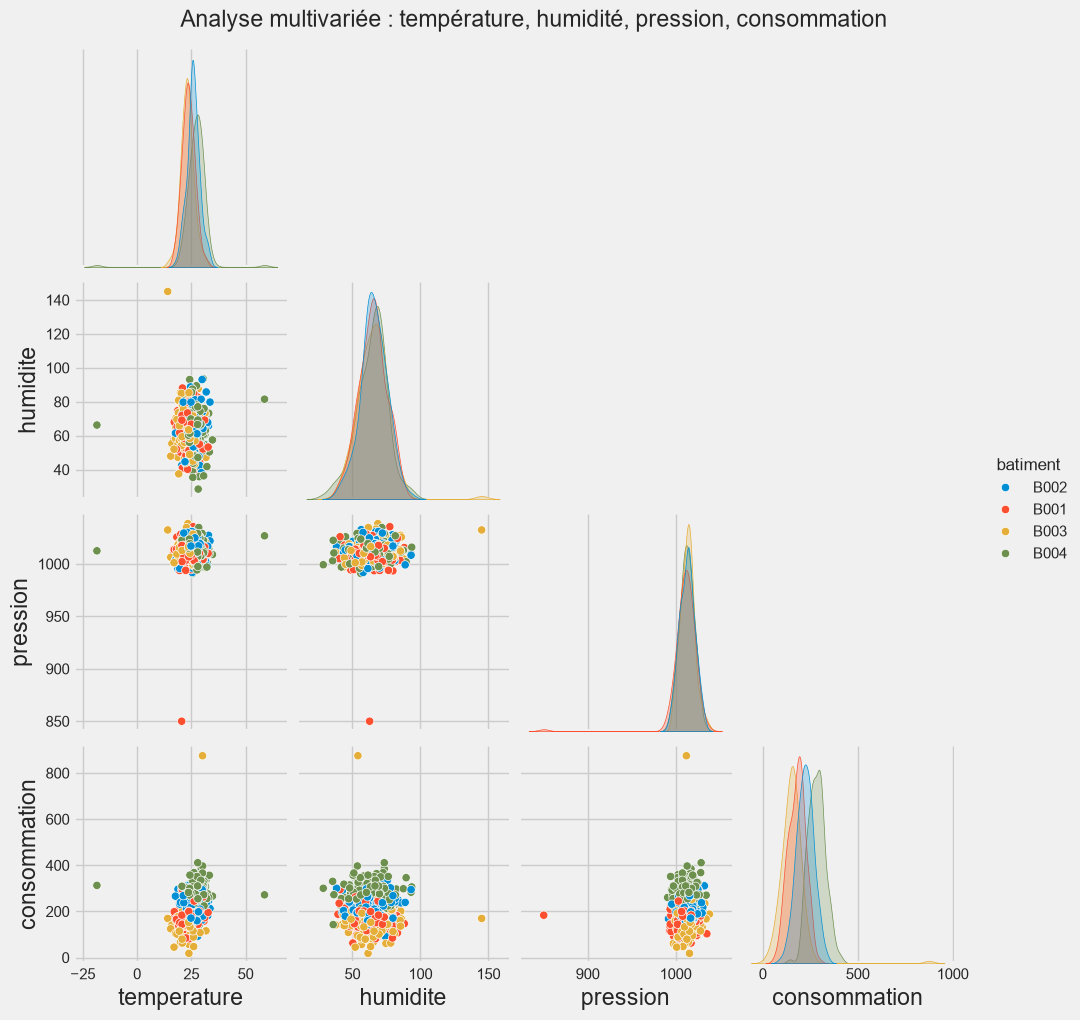

In [112]:

g = sns.pairplot(df[colonnes_num + ["batiment"]], hue="batiment", corner=True)
g.figure.suptitle("Analyse multivariée : température, humidité, pression, consommation", y=1.02)
sauvegarder_grille(g, "pairplot_variables")
plt.show()

---
## Partie 11 – Sauvegarde des graphiques

Chaque graphique du notebook a été sauvegardé au fil de l'eau, directement dans la cellule qui le génère (voir les appels `plt.savefig(...)` / `g.savefig(...)` ci-dessus). On vérifie ici que tout est bien présent dans `exports/`.

In [130]:
fichiers_exportes = sorted(os.listdir("../exports"))
print(f"{len(fichiers_exportes)} fichier(s) dans exports/ :\n")
for f in fichiers_exportes:
    print(" -", f)

35 fichier(s) dans exports/ :

 - boxplot_temperature.pdf
 - boxplot_temperature.png
 - boxplot_temperature_par_batiment.pdf
 - boxplot_temperature_par_batiment.png
 - countplot_batiment.pdf
 - countplot_batiment.png
 - countplot_etat.pdf
 - countplot_etat.png
 - countplot_etat_par_batiment.pdf
 - countplot_etat_par_batiment.png
 - heatmap_correlations.pdf
 - heatmap_correlations.png
 - histplot_temperature_bins_comparaison.pdf
 - histplot_temperature_bins_comparaison.png
 - histplot_temperature_par_batiment.pdf
 - histplot_temperature_par_batiment.png
 - kdeplot_temperature.pdf
 - kdeplot_temperature.png
 - kdeplot_temperature_par_batiment.pdf
 - kdeplot_temperature_par_batiment.png
 - pairplot_variables.png
 - regplot_temperature_consommation.pdf
 - regplot_temperature_consommation.png
 - scatter_temperature_consommation.pdf
 - scatter_temperature_consommation.png
 - scatter_temperature_consommation_par_batiment.pdf
 - scatter_temperature_consommation_par_batiment.png
 - scatter_temp